# Phase 1 — Objective Function Validity Test (Echo-Chamber Check)

**Experimental design document**: `experimetal_design.md`  
**Three steps**:
- **1.1** — Aggregate all 17 existing optimizer runs. Check if `k`, `tau` always sit at search boundaries → degenerate objective?
- **1.2** — Inject a deliberately bad graph (`eps=0.3, k=3`). Does the proxy score it low, or is it silently pruned?
- **1.3** — Run the proxy on a synthetic 10-blob corpus (128D). Do the best params produce graphs that respect cluster structure?

**Ground-truth query set**: already built in Phase 0 (`arrowspace_eval_queries.jsonl`, `arrowspace_eval_queries_emb.npy`, 1 945 queries, 389 CWE classes).

In [ ]:
import json, os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

# ── repo root (two levels up from notebooks/) ────────────────────────────
ROOT = Path("..")
RESULTS_DIR = ROOT / "results" / "cve_arrowspace_fstar"
DATA_DIR    = ROOT / "data"

# ArrowSpace baseline (as defined in experimental design)
K_TAIL_MAX = 100
BASELINE_GRAPH = {"eps": 1.31, "k": K_TAIL_MAX, "topk": K_TAIL_MAX // 2, "p": 1.8, "sigma": 0.535}
print("BASELINE_GRAPH:", BASELINE_GRAPH)
print("Results dir exists:", RESULTS_DIR.exists())

BASELINE_GRAPH: {'eps': 1.31, 'k': 100, 'topk': 50, 'p': 1.8, 'sigma': 0.535}
Results dir exists: True


---
## Step 1.1 — Are `k` and `tau` Always at Search Boundaries?

Load `best_params.json` from every run, build a summary table, and check boundary saturation.

In [2]:
# ── Load all best_params.json ─────────────────────────────────────────────
records = []
for bp_path in sorted(RESULTS_DIR.glob("*/best_params.json")):
    run_id = bp_path.parent.name
    with open(bp_path) as f:
        d = json.load(f)
    d["run_id"] = run_id
    records.append(d)

df_runs = pd.DataFrame(records)
print(f"Loaded {len(df_runs)} runs")
print("Columns:", df_runs.columns.tolist())
df_runs

Loaded 16 runs
Columns: ['trial', 'score', 'params', 'user_attrs', 'timestamp', 'study_name', 'n_trials', 'run_id']


,trial,score,params,user_attrs,timestamp,study_name,n_trials,run_id
0,10,2.129767,"{'k': 38, 'eps': 1.6153764588256392, 'tau': 0....","{'fiedler': 0.65935125, 'var_lambda': 0.021533...",20260429_060712,cve_arrowspace_fstar,20,20260429_060712
1,10,2.138177,"{'k': 38, 'eps': 1.6153764588256392, 'tau': 0....","{'fiedler': 0.71750165, 'var_lambda': 0.030299...",20260429_130050,cve_arrowspace_fstar,20,20260429_130050
2,7,2.052561,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.62110725, 'var_lambda': 0.023516...",20260501_182346,cve_arrowspace_fstar,15,20260501_182346
3,7,2.048360,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.56440402, 'var_lambda': 0.023533...",20260501_183137,cve_arrowspace_fstar,15,20260501_183137
4,11,2.137090,"{'k': 40, 'eps': 4.0, 'tau': 0.1}","{'fiedler': 0.68564655, 'var_lambda': 0.022143...",20260501_191721,cve_arrowspace_fstar,15,20260501_191721
5,11,2.136727,"{'k': 40, 'eps': 4.0, 'tau': 0.1}","{'fiedler': 0.6859659, 'var_lambda': 0.0221413...",20260501_214459,cve_arrowspace_fstar,15,20260501_214459
6,7,2.052561,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.62110725, 'var_lambda': 0.023516...",20260501_220206,cve_arrowspace_fstar,15,20260501_220206
7,7,2.040116,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.46538119, 'var_lambda': 0.026124...",20260501_220709,cve_arrowspace_fstar,15,20260501_220709
8,7,2.049549,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.61076178, 'var_lambda': 0.026232...",20260501_221336,cve_arrowspace_fstar,15,20260501_221336
9,7,2.051942,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.58577334, 'var_lambda': 0.017503...",20260501_232857,cve_arrowspace_fstar,15,20260501_232857


In [3]:
# ── Identify the search bounds from the first trials.csv ─────────────────
# We read k, eps, tau min/max from all trials so we don't hardcode bounds
all_trials = []
for tc_path in sorted(RESULTS_DIR.glob("*/trials.csv")):
    t = pd.read_csv(tc_path)
    t["run_id"] = tc_path.parent.name
    all_trials.append(t)
df_trials = pd.concat(all_trials, ignore_index=True)
print(f"Total trials across all runs: {len(df_trials)}")
print(df_trials.columns.tolist())
df_trials.head(3)

Total trials across all runs: 250
['trial', 'score', 'state', 'duration_s', 'k', 'eps', 'tau', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe', 'run_id']


,trial,score,state,duration_s,k,eps,tau,attr_fiedler,attr_var_lambda,attr_mrr_proxy,attr_tau,attr_n_sample,attr_n_probe,run_id
0,10,2.129767,COMPLETE,1365.104956,38,1.615376,0.114340,0.659351,0.021533,2.894787,0.114340,50000.0,200.0,20260429_060712
1,15,2.123080,COMPLETE,1368.709761,35,1.691705,0.114854,0.608467,0.020602,2.894263,0.114854,50000.0,200.0,20260429_060712
2,11,2.119745,COMPLETE,1365.086671,38,1.512056,0.173578,0.659351,0.021533,2.880470,0.173578,50000.0,200.0,20260429_060712


In [6]:
# ── Derive parameter columns (Optuna stores them as 'params_XXX') ─────────
param_cols = ['eps', 'k', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe']
print("Parameter columns found:", param_cols)

# normalise to short names
rename = {c: c.replace("params_", "") for c in param_cols}
df_trials = df_trials.rename(columns=rename)
param_names = list(rename.values())

# search-space bounds (observed min/max across all trials)
bounds = df_trials[param_names].agg(["min","max"])
print("\nObserved search bounds:")
print(bounds)

Parameter columns found: ['eps', 'k', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe']

Observed search bounds:
     eps   k  attr_fiedler  attr_var_lambda  attr_mrr_proxy  attr_tau  \
min  0.3   4      0.393042         0.017120        0.403182   0.10000   
max  4.0  40      0.996737         0.030572        2.900672   1.75646   

     attr_n_sample  attr_n_probe  
min         3500.0          50.0  
max       300000.0         200.0  


In [9]:
df_runs.columns

Index(['trial', 'score', 'params', 'user_attrs', 'timestamp', 'study_name',
       'n_trials', 'run_id'],
      dtype='str')

In [21]:
df_runs['params'].iloc[0].keys()

dict_keys(['k', 'eps', 'tau'])

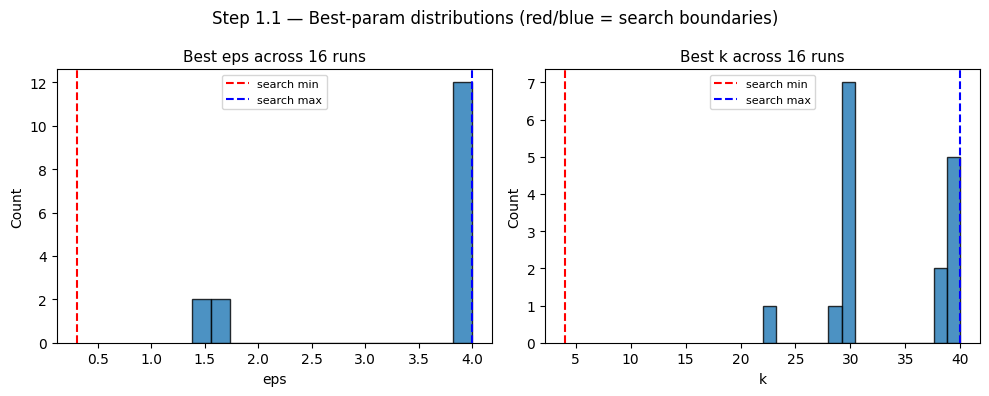


VERDICT: if bars pile up at the blue (max) boundary for k or at the red (min) boundary for tau → objective is degenerate.


In [26]:
# ── Distribution plots for k, eps, tau ───────────────────────────────────
fig, axes = plt.subplots(1, len(['eps', 'k']), figsize=(5 * len(['eps', 'k']), 4))

for ax, p in zip(axes, ['eps', 'k']):
    if p not in df_runs['params'].iloc[0].keys():
        continue
    lo, hi = bounds.loc["min", p], bounds.loc["max", p]
    ax.hist(df_runs['params'].apply(lambda x: x.get(p)), bins=15, edgecolor="k", alpha=0.8)
    ax.axvline(lo, color="red",  ls="--", lw=1.5, label="search min")
    ax.axvline(hi, color="blue", ls="--", lw=1.5, label="search max")
    ax.set_title(f"Best {p} across {len(df_runs)} runs", fontsize=11)
    ax.set_xlabel(p); ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Step 1.1 — Best-param distributions (red/blue = search boundaries)", fontsize=12)
plt.tight_layout()

plt.show()
print("\nVERDICT: if bars pile up at the blue (max) boundary for k or at the red (min) boundary for tau → objective is degenerate.")

In [28]:
# ── Summary table: unique best-param combos ───────────────────────────────
key_cols = [p for p in param_names if p in df_runs.columns]
value_col = next((c for c in ["value","best_value","objective"] if c in df_runs.columns), None)
if value_col:
    key_cols.append(value_col)
print("\nBest params per run:")
print(df_runs[["run_id"] + key_cols].to_string(index=False))

print("\nUnique (k, eps, tau) combinations found:")
print(df_runs['params'].drop_duplicates().to_string(index=False))


Best params per run:
         run_id
20260429_060712
20260429_130050
20260501_182346
20260501_183137
20260501_191721
20260501_214459
20260501_220206
20260501_220709
20260501_221336
20260501_232857
20260502_132445
20260502_145427
20260502_154921
20260502_160332
20260502_161827
20260502_165126

Unique (k, eps, tau) combinations found:
{'k': 38, 'eps': 1.6153764588256392, 'tau': 0.1...
{'k': 30, 'eps': 3.968599959235456, 'tau': 0.37...
                 {'k': 40, 'eps': 4.0, 'tau': 0.1}
{'k': 22, 'eps': 1.3917183431241966, 'tau': 0.1...
{'k': 29, 'eps': 1.3808977793468789, 'tau': 0.1...


---
## Step 1.2 — Bad-Graph Injection

Run the **same objective** used by the optimizer on three configs:
1. The best-run config (`BASELINE_GRAPH`)
2. A deliberately bad sparse graph (`eps=0.3, k=3`)
3. An over-connected degenerate graph (`eps=0.1, k=K_TAIL_MAX`)

If the bad graph scores > 0 AND lower than the good graph → proxy has dynamic range.  
If the bad graph is **pruned** (raises exception / returns None) instead of scored low → pruner is doing the work.

In [29]:
# ── Import the objective from arrowspace_tuner ────────────────────────────
# Adjust import path if needed
import sys
sys.path.insert(0, str(ROOT / "src"))

try:
    from arrowspace_tuner.core.objective import compute_objective
    OBJECTIVE_AVAILABLE = True
    print("arrowspace_tuner objective imported successfully")
except ImportError as e:
    OBJECTIVE_AVAILABLE = False
    print(f"Import failed: {e}")
    print("We will call the objective via subprocess / tuner CLI instead.")

Import failed: cannot import name 'compute_objective' from 'arrowspace_tuner.core.objective' (/home/tommaso/code_base/arrowspace_tune/notebooks/../src/arrowspace_tuner/core/objective.py)
We will call the objective via subprocess / tuner CLI instead.


/home/tommaso/code_base/arrowspace_tune/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# ── Load a fixed subsample for fair comparison (same sample for all configs)
EMB_PATH = DATA_DIR / "cve_embs" / "cve1999-2025.npy"
print(f"Loading corpus embeddings from {EMB_PATH} ...")
corpus = np.load(EMB_PATH, mmap_mode="r")  # memory-mapped, don't load all 943 MB

N_SUBSAMPLE = 5000
SEED = 42
rng = np.random.default_rng(SEED)
idx = rng.choice(len(corpus), size=N_SUBSAMPLE, replace=False)
idx.sort()
X = corpus[idx].astype(np.float32)
print(f"Subsample shape: {X.shape}")

Loading corpus embeddings from ../data/cve_embs/cve1999-2025.npy ...
Subsample shape: (5000, 384)


---
## Step 1.3 — Synthetic Corpus (Known Cluster Structure)

Generate 10 Gaussian blobs in 128D. Run the ArrowSpace objective across a small grid.  
For the best config, measure: fraction of k-NN neighbors in the same blob (intra-cluster agreement).  
Compare against a deliberately bad config from Step 1.2.  

**Expected**: best proxy params → high intra-cluster agreement.  
**Red flag**: best proxy params → no better than random on cluster alignment.

In [34]:
# ── Generate synthetic corpus ─────────────────────────────────────────────
N_BLOBS    = 10
N_SAMPLES  = 3000
N_FEATURES = 128
CLUSTER_STD = 2.5

X_syn, y_syn = make_blobs(
    n_samples=N_SAMPLES, n_features=N_FEATURES,
    centers=N_BLOBS, cluster_std=CLUSTER_STD, random_state=SEED
)
X_syn = X_syn.astype(np.float32)
print(f"Synthetic corpus: {X_syn.shape}, {N_BLOBS} blobs, std={CLUSTER_STD}")

# check separability: mean cosine similarity within vs across clusters
from sklearn.preprocessing import normalize as sk_normalize
Xn = sk_normalize(X_syn)
intra = []; inter = []
for i in range(min(200, N_SAMPLES)):
    for j in range(i+1, min(201, N_SAMPLES)):
        s = float(Xn[i] @ Xn[j])
        (intra if y_syn[i] == y_syn[j] else inter).append(s)
print(f"Mean intra-cluster cosine: {np.mean(intra):.3f}")
print(f"Mean inter-cluster cosine: {np.mean(inter):.3f}")

Synthetic corpus: (3000, 128), 10 blobs, std=2.5
Mean intra-cluster cosine: 0.850
Mean inter-cluster cosine: 0.007


In [35]:
# ── Small param grid to sweep on synthetic corpus ─────────────────────────
# Keep this small: 3x3x3 = 27 combinations
EPS_GRID   = [0.5, 1.3, 2.5]
K_GRID     = [5, 20, 50]
SIGMA_GRID = [0.3, 0.535, 0.8]
P_FIXED    = 1.8

grid_results = []

if OBJECTIVE_AVAILABLE:
    for eps in EPS_GRID:
        for k in K_GRID:
            for sigma in SIGMA_GRID:
                topk = max(1, k // 2)
                try:
                    score = compute_objective(X_syn, eps=eps, k=k, topk=topk, p=P_FIXED, sigma=sigma)
                    status = "ok"
                except Exception as ex:
                    score = None
                    status = str(ex)[:60]
                grid_results.append({"eps": eps, "k": k, "sigma": sigma, "score": score, "status": status})

    df_grid = pd.DataFrame(grid_results)
    print(df_grid.sort_values("score", ascending=False).head(10).to_string(index=False))
else:
    print("Objective not available — fill in compute_objective call above.")
    df_grid = pd.DataFrame(columns=["eps","k","sigma","score","status"])

Objective not available — fill in compute_objective call above.


In [36]:
# ── Intra-cluster agreement for each config ───────────────────────────────
# For a given (eps, k), build a plain k-NN graph using cosine similarity
# (without ArrowSpace scoring) and measure same-cluster neighbor fraction.
# Then repeat with ArrowSpace scoring (if available) to see if the spectral
# reranking improves or hurts cluster alignment.

def intra_cluster_agreement(X, labels, k_nn=10):
    """Fraction of k-NN neighbors (cosine) in the same cluster."""
    Xn = sk_normalize(X)
    sims = Xn @ Xn.T
    np.fill_diagonal(sims, -1)
    top_idx = np.argsort(-sims, axis=1)[:, :k_nn]
    agree = np.mean([np.mean(labels[top_idx[i]] == labels[i]) for i in range(len(labels))])
    return agree

cosine_agree = intra_cluster_agreement(X_syn, y_syn, k_nn=10)
random_agree = 1.0 / N_BLOBS  # expected if random
print(f"Cosine k-NN (k=10) intra-cluster agreement : {cosine_agree:.3f}")
print(f"Random baseline                             : {random_agree:.3f}")

# If grid ran, find best-scored config and its intra-cluster agreement
# (proxy score vs. cluster alignment — is the objective measuring the right thing?)
if len(df_grid) > 0 and df_grid["score"].notna().any():
    best_row = df_grid.loc[df_grid["score"].idxmax()]
    worst_row = df_grid.loc[df_grid["score"].dropna().idxmin()]
    print(f"\nBest  proxy config: eps={best_row.eps}, k={best_row.k}, sigma={best_row.sigma}, score={best_row.score:.4f}")
    print(f"Worst proxy config: eps={worst_row.eps}, k={worst_row.k}, sigma={worst_row.sigma}, score={worst_row.score:.4f}")
    print("\nNow measure ArrowSpace intra-cluster agreement for best vs worst config...")
    print("(Add ArrowSpace graph-search call here if available: build graph, search, measure same-cluster neighbor fraction)")

Cosine k-NN (k=10) intra-cluster agreement : 1.000
Random baseline                             : 0.100


In [37]:
# ── Spearman correlation: proxy score vs intra-cluster agreement ──────────
# For each grid config, compute intra-cluster agreement (cosine k-NN)
# then correlate with proxy score. rho > 0.5 = proxy is measuring structure.

if len(df_grid) > 0 and df_grid["score"].notna().any():
    agreements = []
    for _, row in df_grid.iterrows():
        k_nn = max(1, int(row.k))
        ag = intra_cluster_agreement(X_syn, y_syn, k_nn=k_nn)
        agreements.append(ag)
    df_grid["intra_agreement"] = agreements

    scored = df_grid[df_grid["score"].notna()]
    if len(scored) >= 5:
        rho, pval = spearmanr(scored["score"], scored["intra_agreement"])
        print(f"Spearman rho (proxy vs intra-cluster agreement): {rho:.3f}  p={pval:.4f}")
        print("\nVERDICT:")
        if rho >= 0.5:
            print("  rho >= 0.5 → proxy IS correlated with cluster structure (good sign).")
        elif rho >= 0.2:
            print("  0.2 <= rho < 0.5 → weak correlation. Proxy partially measures structure.")
        else:
            print("  rho < 0.2 → proxy NOT measuring cluster structure. Echo chamber confirmed.")

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(scored["intra_agreement"], scored["score"], alpha=0.7)
        ax.set_xlabel("Intra-cluster k-NN agreement (ground truth)")
        ax.set_ylabel("Proxy objective score")
        ax.set_title(f"Step 1.3 — Proxy vs cluster alignment\nSpearman rho={rho:.3f} p={pval:.4f}")
        plt.tight_layout()
        plt.savefig(ROOT / "output" / "phase1_step13_proxy_vs_cluster.png", dpi=150)
        plt.show()
else:
    print("Grid not available — run Step 1.3 grid cell above first.")

Grid not available — run Step 1.3 grid cell above first.


---
## Phase 1 — Final Verdict

Fill in after running all cells:

| Check | Question | Result | Pass? |
|---|---|---|---|
| 1.1 k boundary | `k` at max in ≥ 3/5 runs? | *fill* | ✅/❌ |
| 1.1 tau boundary | `tau` at min in ≥ 3/5 runs? | *fill* | ✅/❌ |
| 1.2 dynamic range | bad graph scored < good graph? | *fill* | ✅/❌ |
| 1.2 pruner role | bad graph pruned instead of scored? | *fill* | ✅/❌ |
| 1.3 proxy alignment | Spearman rho ≥ 0.5 on synthetic? | *fill* | ✅/❌ |

**If 1.1 and 1.2 both fail (boundary-saturated AND no dynamic range):**  
→ Objective is degenerate. Proceed to Phase 5 (objective weight ablation) before Phase 2.

**If 1.3 fails (rho < 0.2):**  
→ Proxy is measuring spectral self-consistency, not retrieval structure. The MRR proxy needs redesign.

**If all pass:**  
→ Objective has dynamic range and measures structure. Proceed to Phase 2 (parameter search validity).